In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import ast
import math
import cmath

In [5]:
h1 = 1
m = 0.5
def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1) / (h1**2)
    constant_2 = 2 * m * (y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [6]:
# 参数设置
N = 1
n3 = 0
n4 = 0
y1 = 2
y2 = 2
E=0.1                              #E_set = np.linspace(0.0000001,400,40000)
a_set =np.linspace(0, 20, 10000)                    #######np.linspace(0, 20, 10000)

# 计算数据
T_set = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set]
R_set = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for a in a_set]
Sum_set = [T + R for T, R in zip(T_set, R_set)]
# 创建DataFrame保存数据
data = {
    'a_set': a_set,
    'T_set': T_set,
    'R_set': R_set,
    'Sum_set': Sum_set
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_E{E}_a_change{2}.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

NameError: name 'Y1' is not defined

In [123]:
# 读取 Excel 文件
N = 1
n3 = 0
n4 = 0
y1 = Y1
y2 = Y2
E=0.1  
file_name = f"N{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_E{E}_a_change{2}.xlsx"
save_dir=r"C:\Users\taoji\Desktop\结果\2025.5.3后_Python运行结果"
save_path = os. path.join(save_dir, file_name)
loaded_df = pd.read_excel(save_path)

# 将字符串形式的列表转换为实际的列表
def safe_literal_eval(x):
    if isinstance(x, str):  # 如果是字符串才尝试解析
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x
    else:  # 已经是数字或列表就直接返回
        return x

a_set = loaded_df["a_set"].apply(safe_literal_eval)
T_set = loaded_df["T_set"].apply(safe_literal_eval)
R_set = loaded_df["R_set"].apply(safe_literal_eval)
Sum_values_set = loaded_df["Sum_set"].apply(safe_literal_eval)



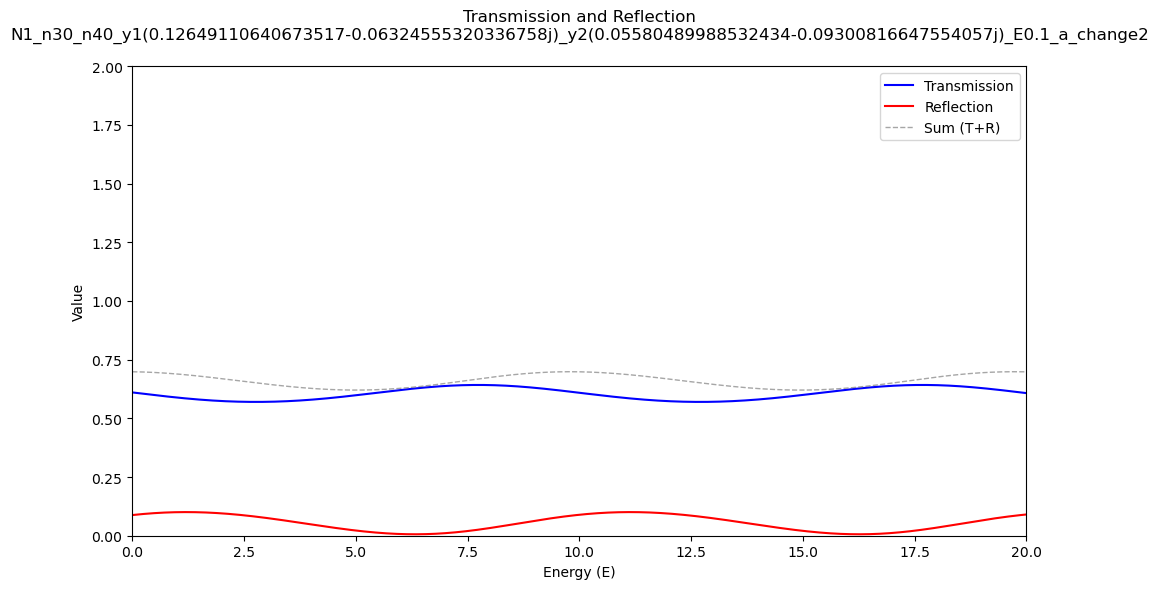

In [124]:
plt.figure(figsize=(10, 6))
plt.plot(a_set, T_set,color='blue',label='Transmission')  
plt.plot(a_set, R_set,color='red',label='Reflection')  
plt.plot(a_set, Sum_set, 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')
plt.title(f'Transmission and Reflection\nN{N}_n3{n3}_n4{n4}_y1{y1}_y2{y2}_E{E}_a_change{2}', pad=20)
plt.xlabel('Energy (E)')
plt.ylabel('Value')

plt.ylim(0, 2)
plt.xlim(0,20)
#ax.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=3.687850, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=47.240296550706, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=157.913670417430, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=165.848348494293, color='green', linestyle='-', linewidth=1, alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

In [104]:
m=0.5
k=4**0.5
Y1=2
Y2=2
d1=k/(m*Y1)
d2=k/(m*Y2)
a=0.7
#a1=np.linspace(0, 20, 1000)
#print(d1,d2)

In [105]:
#正射
R_dan=(1-d2*1j-(1+d1*1j)*np.exp(2j*a*k))/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
T_dan=(d1*d2/((d1+1j)*(d2+1j)+np.exp(2j*a*k)))
print('粒子正射的反射系数',R_dan,'\n','粒子正射的透射系数',T_dan)

粒子正射的反射系数 (0.14862062542087462-0.5320361575130473j) 
 粒子正射的透射系数 (0.3574614119106062-0.7530410186657404j)


In [106]:
#反射
R_dan_1=(-1-1j*d2+(1-d1*1j)*np.exp(-2j*a*k))/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
T_dan_1=(d1*d2/((d1*d2+1j*(d1+d2)-1)+np.exp(2j*a*k)))
print('粒子反射的透射系数',T_dan_1,'\n','粒子反射的反射系数',R_dan_1)

粒子反射的透射系数 (0.3574614119106062-0.7530410186657404j) 
 粒子反射的反射系数 (-0.3182594817770479+0.4515102052675498j)


In [107]:
print(cmath.log(R_dan/R_dan_1),k*2*a*1j)

2.8j 2.8j


In [8]:
T_22=[abs(d1*d2/((d1+1j)*(d2+1j)+np.exp(2j*a*k)))**2 for a in a1]
R_22=[abs((1-d2*1j-(1+d1*1j)*np.exp(2j*a*k))/((d1+1j)*(d2+1j)+np.exp(2j*a*k)))**2 for a in a1]
Sum_22 = [T + R for T, R in zip(T_22, R_22)]

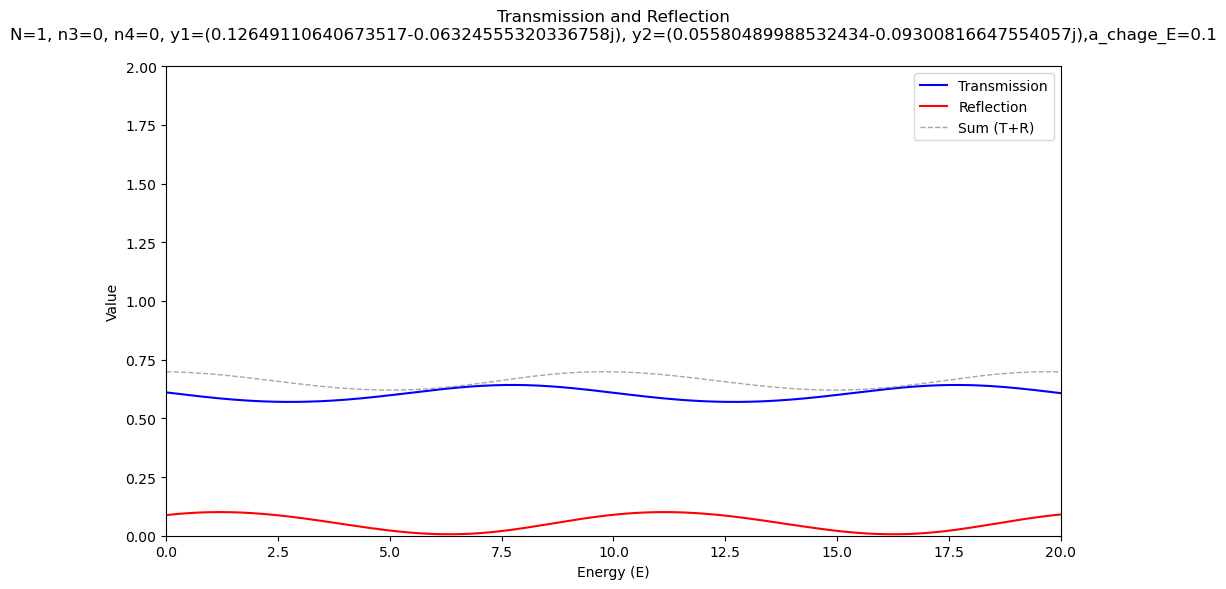

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(a1, T_22,color='blue',label='Transmission')  
plt.plot(a1, R_22,color='red',label='Reflection')  
plt.plot(a1, Sum_22 , 
         color='gray', linestyle='--', 
         linewidth=1, alpha=0.7,
         label='Sum (T+R)')
plt.title(f'Transmission and Reflection\nN={N}, n3={n3}, n4={n4}, y1={Y1}, y2={Y2},a_chage_E=0.1' ,pad=20)
plt.xlabel('Energy (E)')
plt.ylabel('Value')

plt.ylim(0, 2)
plt.xlim(0,20)
#ax.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=3.687850, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=47.240296550706, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=157.913670417430, color='green', linestyle='-', linewidth=1, alpha=0.7)
#ax.axvline(x=165.848348494293, color='green', linestyle='-', linewidth=1, alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
A=d1*(d2+1j)/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
B=-1j*d1*np.exp(2j*a*k)/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
D=d1*d2/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
R=(1-d2*1j-(1+d1*1j)*np.exp(2j*a*k))/((d1+1j)*(d2+1j)+np.exp(2j*a*k))
print(abs(A)**2-abs(B)**2, abs(D)**2, abs(R)**2)

25.0

1.6366197723675815
